In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

In [3]:
# 1. LOAD DATASET
data = pd.read_csv("iot_telemetry_data.csv")

data_original = data.copy()

print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (405184, 9)
             ts             device        co   humidity  light       lpg  \
0  1.594512e+09  b8:27:eb:bf:9d:51  0.004956  51.000000  False  0.007651   
1  1.594512e+09  00:0f:00:70:91:0a  0.002840  76.000000  False  0.005114   
2  1.594512e+09  b8:27:eb:bf:9d:51  0.004976  50.900000  False  0.007673   
3  1.594512e+09  1c:bf:ce:15:ec:4d  0.004403  76.800003   True  0.007023   
4  1.594512e+09  b8:27:eb:bf:9d:51  0.004967  50.900000  False  0.007664   

   motion     smoke       temp  
0   False  0.020411  22.700000  
1   False  0.013275  19.700001  
2   False  0.020475  22.600000  
3   False  0.018628  27.000000  
4   False  0.020448  22.600000  


In [4]:
# -----------------------------
# 2. PREPROCESSING FOR MODEL
# -----------------------------

# Remove unwanted columns ONLY for model
data_model = data.drop(['device', 'ts'], axis=1)

# Separate columns
categorical_cols = data_model.select_dtypes(include=["object"]).columns
numerical_cols = data_model.select_dtypes(include=["int64", "float64"]).columns

# Handle missing values
imputer = SimpleImputer(strategy="mean")
data_model[numerical_cols] = imputer.fit_transform(data_model[numerical_cols])

# Encode categorical
for col in categorical_cols:
    le = LabelEncoder()
    data_model[col] = le.fit_transform(data_model[col])

# Scale
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_model)

data_model = pd.DataFrame(data_scaled, columns=data_model.columns)

print("Preprocessing Completed ")

Preprocessing Completed 


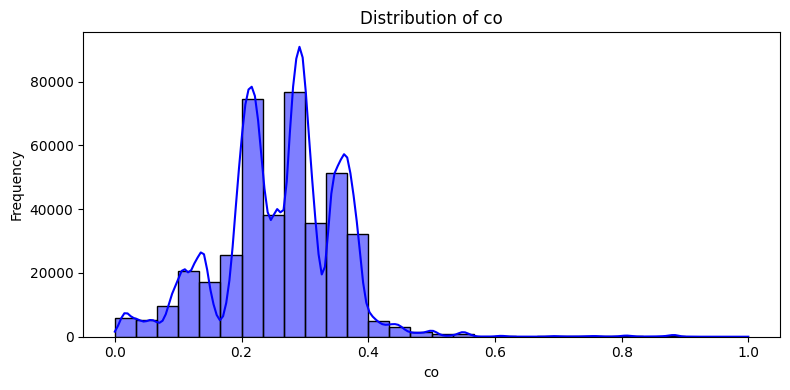

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.histplot(
    data_model["co"],
    bins=30,           
    kde=True,
    stat="count",
    color="blue",
    edgecolor="black"
)

plt.title("Distribution of co")
plt.xlabel("co")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

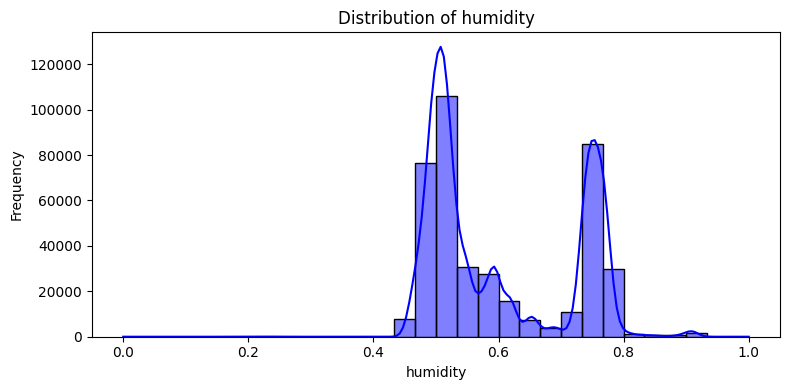

In [6]:
plt.figure(figsize=(8,4))

sns.histplot(
    data_model["humidity"],
    bins=30,           
    kde=True,
    stat="count",
    color="blue",
    edgecolor="black"
)

plt.title("Distribution of humidity")
plt.xlabel("humidity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

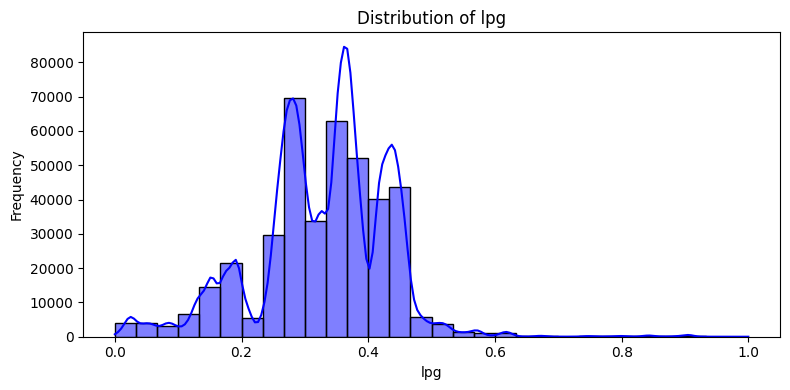

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.histplot(
    data_model["lpg"],
    bins=30,          
    kde=True,
    stat="count",
    color="blue",
    edgecolor="black"
)

plt.title("Distribution of lpg")
plt.xlabel("lpg")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

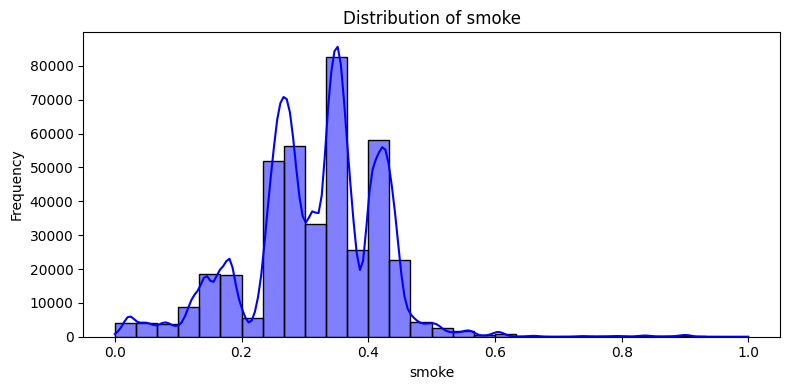

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.histplot(
    data_model["smoke"],
    bins=30,           
    kde=True,
    stat="count",
    color="blue",
    edgecolor="black"
)

plt.title("Distribution of smoke")
plt.xlabel("smoke")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [9]:
# 3. TRAIN ISOLATION FOREST
import time
start = time.time()

# Use only sensor features
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42
)

iso_model.fit(data_model)
end = time.time()

print("Execution Time:", end - start)

anomaly_scores = iso_model.decision_function(data_model)

print(anomaly_scores)

Execution Time: 2.8131136894226074
[0.13405971 0.07929091 0.13531834 ... 0.02308579 0.09456021 0.10687903]


In [10]:
predictions = iso_model.predict(data_model)

labels = np.where(predictions == -1, 1, 0)



# Keep device & ts
meta_cols = data_original[['device', 'ts']].reset_index(drop=True)

# Scaled features
data_model = data_model.reset_index(drop=True)

# Combine everything
final_data = pd.concat([meta_cols, data_model], axis=1)

# Add labels
final_data["is_anomaly"] = labels

print(final_data.head())

# -----------------------------
# 5. SAVE FINAL DATASET
# -----------------------------
data_original['is_anomaly'] = labels
data_original.to_csv("original_sensor_data.csv", index=False)   
final_data.to_csv("labeled_sensor_data.csv", index=False)

print("Saved scaled data with device & ts ")

print("Saved with device & ts ")

print(final_data["is_anomaly"].value_counts())

              device            ts        co  humidity  light       lpg  \
0  b8:27:eb:bf:9d:51  1.594512e+09  0.285702  0.505061    0.0  0.357314   
1  00:0f:00:70:91:0a  1.594512e+09  0.126010  0.758097    0.0  0.174493   
2  b8:27:eb:bf:9d:51  1.594512e+09  0.287217  0.504049    0.0  0.358929   
3  1c:bf:ce:15:ec:4d  1.594512e+09  0.243971  0.766194    1.0  0.312087   
4  b8:27:eb:bf:9d:51  1.594512e+09  0.286564  0.504049    0.0  0.358234   

   motion     smoke      temp  is_anomaly  
0     0.0  0.343856  0.741830           0  
1     0.0  0.164989  0.643791           0  
2     0.0  0.345456  0.738562           0  
3     0.0  0.299166  0.882353           0  
4     0.0  0.344767  0.738562           0  
Saved scaled data with device & ts 
Saved with device & ts 
is_anomaly
0    364695
1     40489
Name: count, dtype: int64


0   2020-07-12 00:01:34.385974646
1   2020-07-12 00:01:34.735567570
2   2020-07-12 00:01:38.073572874
3   2020-07-12 00:01:39.589145899
4   2020-07-12 00:01:41.761234999
Name: ts, dtype: datetime64[ns]


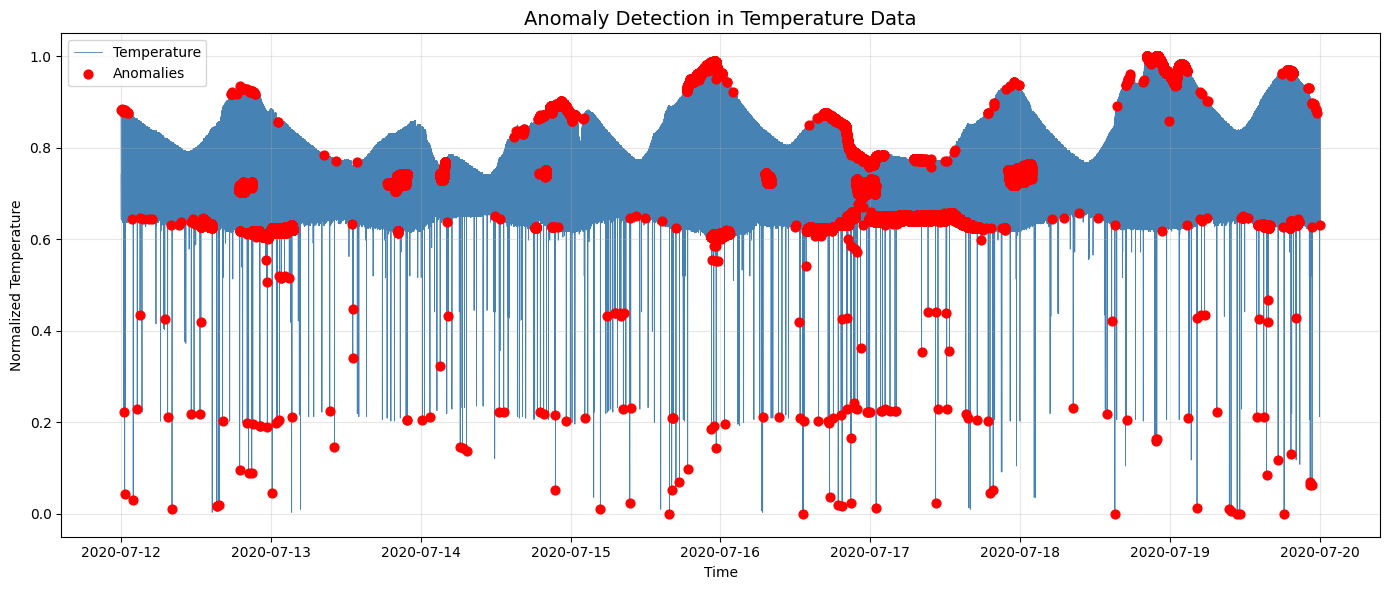

In [11]:
import matplotlib.pyplot as plt

# Load labeled dataset
data = pd.read_csv("labeled_sensor_data.csv")  # Use the scaled data with labels for visualization

# Convert timestamp to datetime (if exists)
if "ts" in data.columns:
    data["ts"] = pd.to_numeric(data["ts"], errors="coerce")
    data["ts"] = pd.to_datetime(data["ts"], unit="s")
    print(data["ts"].head())

plt.figure(figsize=(14, 6))

# Plot humidity line
plt.plot(
    data["ts"],
    data["temp"],
    color="steelblue",
    linewidth=0.6,
    label="Temperature",
    zorder=1
)

# Plot anomalies (red dots)
anomalies = data[data["is_anomaly"] == 1]

plt.scatter(
    anomalies["ts"],
    anomalies["temp"],
    color="red",
    s=40,
    label="Anomalies",
    zorder=3
)

plt.title("Anomaly Detection in Temperature Data", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Normalized Temperature")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

0   2020-07-12 00:01:34.385974646
1   2020-07-12 00:01:34.735567570
2   2020-07-12 00:01:38.073572874
3   2020-07-12 00:01:39.589145899
4   2020-07-12 00:01:41.761234999
Name: ts, dtype: datetime64[ns]


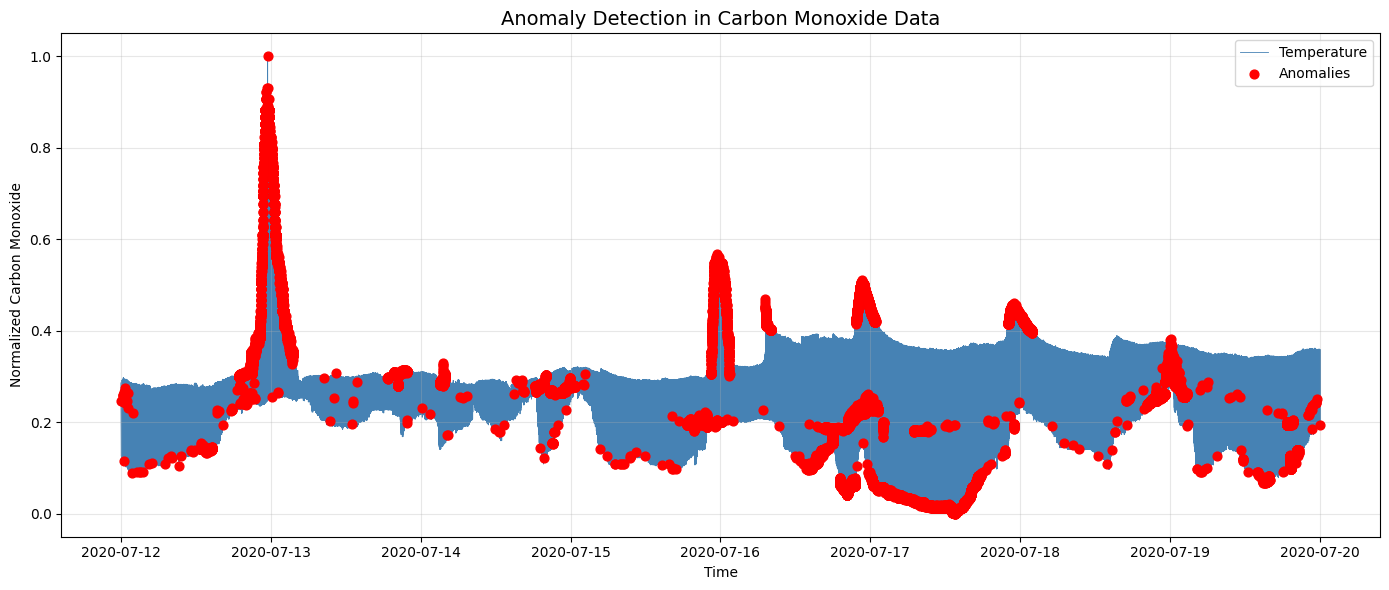

In [12]:
import matplotlib.pyplot as plt

# Load labeled dataset
data = pd.read_csv("labeled_sensor_data.csv")  # Use the scaled data with labels for visualization

# Convert timestamp to datetime (if exists)
if "ts" in data.columns:
    data["ts"] = pd.to_numeric(data["ts"], errors="coerce")
    data["ts"] = pd.to_datetime(data["ts"], unit="s")
    print(data["ts"].head())

plt.figure(figsize=(14, 6))

# Plot humidity line
plt.plot(
    data["ts"],
    data["co"],
    color="steelblue",
    linewidth=0.6,
    label="Temperature",
    zorder=1
)

# Plot anomalies (red dots)
anomalies = data[data["is_anomaly"] == 1]

plt.scatter(
    anomalies["ts"],
    anomalies["co"],
    color="red",
    s=40,
    label="Anomalies",
    zorder=3
)

plt.title("Anomaly Detection in Carbon Monoxide Data", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Normalized Carbon Monoxide")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

0   2020-07-12 00:01:34.385974646
1   2020-07-12 00:01:34.735567570
2   2020-07-12 00:01:38.073572874
3   2020-07-12 00:01:39.589145899
4   2020-07-12 00:01:41.761234999
Name: ts, dtype: datetime64[ns]


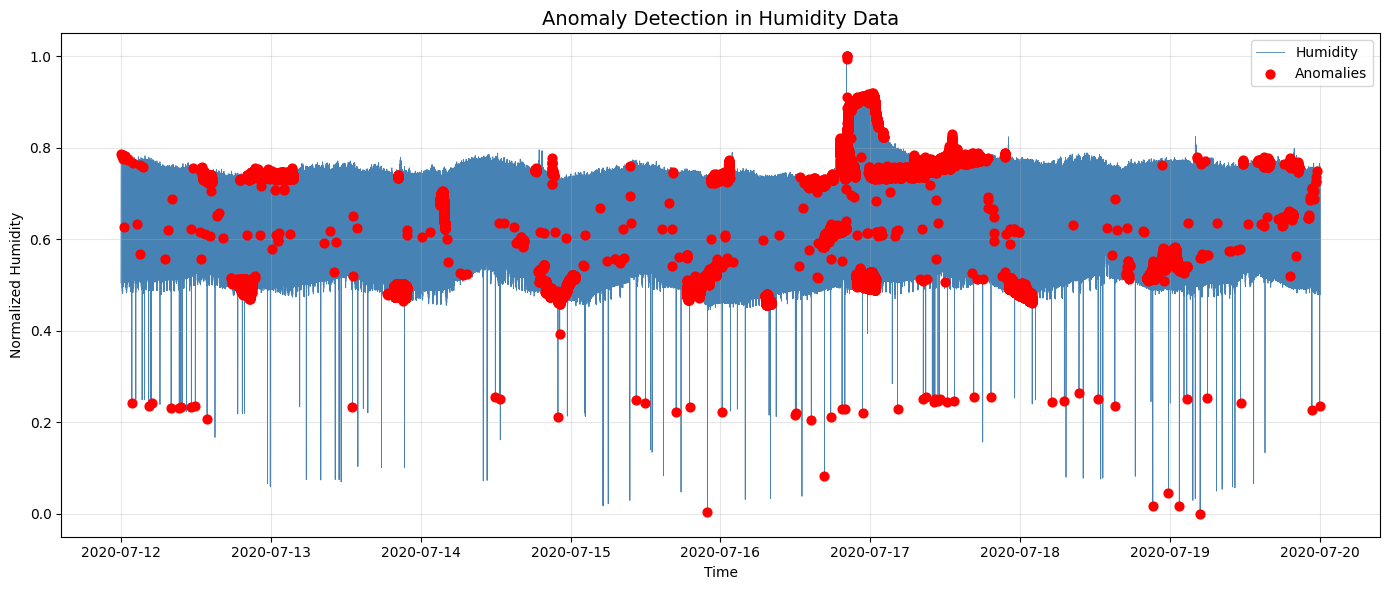

In [13]:
import matplotlib.pyplot as plt

# Load labeled dataset
data = pd.read_csv("labeled_sensor_data.csv")  # Use the scaled data with labels for visualization

# Convert timestamp to datetime (if exists)
if "ts" in data.columns:
    data["ts"] = pd.to_numeric(data["ts"], errors="coerce")
    data["ts"] = pd.to_datetime(data["ts"], unit="s")
    print(data["ts"].head())

plt.figure(figsize=(14, 6))

# Plot humidity line
plt.plot(
    data["ts"],
    data["humidity"],
    color="steelblue",
    linewidth=0.6,
    label="Humidity",
    zorder=1
)

# Plot anomalies (red dots)
anomalies = data[data["is_anomaly"] == 1]

plt.scatter(
    anomalies["ts"],
    anomalies["humidity"],
    color="red",
    s=40,
    label="Anomalies",
    zorder=3
)

plt.title("Anomaly Detection in Humidity Data", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Normalized Humidity")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# STAGE 2: SUPERVISED LEARNING (Random Forest)
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------
# 1. LOAD LABELED DATASET (From Stage 1)
# ------------------------------------------
data = pd.read_csv("labeled_sensor_data.csv")

print("Dataset Shape:", data.shape)

# ------------------------------------------
# 2. DEFINE FEATURES & TARGET
# ------------------------------------------
X = data.drop(columns=["is_anomaly","device","ts"])
y = data["is_anomaly"]
print("Features Shape:", X.head())
print("Target Shape:", y.shape)

# ------------------------------------------
# 3. TRAIN-TEST SPLIT (70-30 like paper)
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# 4. TRAIN RANDOM FOREST MODEL
# ------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,

)

rf_model.fit(X_train, y_train)

print("Model Training Completed ")

# ------------------------------------------
# 5. EVALUATE MODEL
# ------------------------------------------
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Model Performance ---")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))  

print(rf_model.predict_proba(X_test[:10]))

Dataset Shape: (405184, 10)
Features Shape:          co  humidity  light       lpg  motion     smoke      temp
0  0.285702  0.505061    0.0  0.357314     0.0  0.343856  0.741830
1  0.126010  0.758097    0.0  0.174493     0.0  0.164989  0.643791
2  0.287217  0.504049    0.0  0.358929     0.0  0.345456  0.738562
3  0.243971  0.766194    1.0  0.312087     0.0  0.299166  0.882353
4  0.286564  0.504049    0.0  0.358234     0.0  0.344767  0.738562
Target Shape: (405184,)
Model Training Completed 

--- Model Performance ---
Accuracy : 0.999
Precision: 0.9956
Recall   : 0.9942
F1 Score : 0.9949

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    109409
           1       1.00      0.99      0.99     12147

    accuracy                           1.00    121556
   macro avg       1.00      1.00      1.00    121556
weighted avg       1.00      1.00      1.00    121556

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]


In [1]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# 1. MODEL (simple + stable)
# -----------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# -----------------------------
# 2. TRAIN
# -----------------------------
mlp.fit(X_train, y_train)

# -----------------------------
# -----------------------------
y_prob = mlp.predict_proba(X_test)[:, 1]
y_pred_mlp = (y_prob > 0.45).astype(int)

# -----------------------------
# 4. EVALUATE
# -----------------------------
accuracy = accuracy_score(y_test, y_pred_mlp)
precision = precision_score(y_test, y_pred_mlp)
recall = recall_score(y_test, y_pred_mlp)
f1 = f1_score(y_test, y_pred_mlp)

print("\n--- Neural Network Performance ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))  


NameError: name 'X_train' is not defined

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

base_model = DecisionTreeClassifier(max_depth=2)

adb = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100,
    random_state=42
)
adb.fit(X_train, y_train)

# Predict
y_pred_adb = adb.predict(X_test)

# Evaluate
print("\n--- AdaBoost Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_adb))
print("Precision:", precision_score(y_test, y_pred_adb))
print("Recall   :", recall_score(y_test, y_pred_adb))
print("F1 Score :", f1_score(y_test, y_pred_adb))



--- AdaBoost Performance ---
Accuracy : 0.9887294744808977
Precision: 0.9765631909436632
Recall   : 0.9090310364699102
F1 Score : 0.9415877888633069


In [17]:
import shap


explainer = shap.TreeExplainer(rf_model)

In [18]:
def predict_and_explain(input_data, scaler, model, explainer, feature_names):
    
    import pandas as pd
    import numpy as np

    # -----------------------------
    # 1. Convert to DataFrame
    # -----------------------------
    user_df = pd.DataFrame([input_data])

    # Ensure correct column order
    user_df = user_df[feature_names]

    # -----------------------------
    # 2. APPLY SCALING (IMPORTANT)
    # -----------------------------
    user_scaled = scaler.transform(user_df)
    user_scaled = pd.DataFrame(user_scaled, columns=feature_names)

    # -----------------------------
    # 3. PREDICTION
    # -----------------------------
    pred = model.predict(user_scaled)[0]
    prob = model.predict_proba(user_scaled)[0]

    print("\n Prediction Probability:")
    print(f"Normal: {prob[0]:.4f}, Anomaly: {prob[1]:.4f}")

    if pred == 1:
        print("\nAnomaly Detected")
    else:
        print("\nNormal")

    # -----------------------------
    # 4. SHAP EXPLANATION
    # -----------------------------
    shap_values = explainer.shap_values(user_scaled)

    # Handle different SHAP formats
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]

    # -----------------------------
    # 5. TEXT EXPLANATION
    # -----------------------------
    feature_impact = pd.Series(shap_values[0], index=feature_names)
    feature_impact = feature_impact.sort_values(ascending=False)

    print("\n Top reasons:")
    for feature, value in feature_impact.head(3).items():
        print(f"{feature} → impact: {value:.4f}")

    # -----------------------------
    # 6. VISUAL EXPLANATION (OPTIONAL)
    # -----------------------------
    import shap
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value[1],
            data=user_scaled.iloc[0],
            feature_names=feature_names
        )
    )


 Prediction Probability:
Normal: 0.0000, Anomaly: 1.0000

Anomaly Detected

 Top reasons:
light → impact: 0.4169
lpg → impact: 0.1501
co → impact: 0.1420


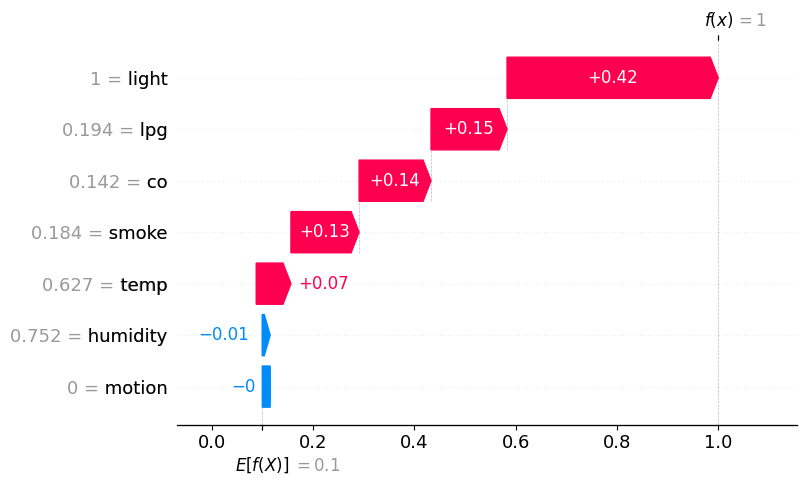

In [19]:
input_data = {
    'co': 0.003048879,
    'humidity': 75.90000153,
    'light': 0,
    'lpg': 0.005383692,
    'motion': 0,
    'smoke': 0.014022829,
    'temp': 19.60000038
}


input_data1 = {
    'co': 0.003048879,
    'humidity': 75.40000153,
    'light': 1,
    'lpg': 0.005383692,
    'motion': 0,
    'smoke': 0.014022829,
    'temp': 19.20000076
}

	


predict_and_explain(
    input_data1,
    scaler,         
    rf_model,
    explainer,
    X_train.columns
)
						


